In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("C:\\Users\\kiran\\OneDrive\\Desktop\\intern river\\matches.csv")
deliveries = pd.read_csv("C:\\Users\\kiran\\OneDrive\\Desktop\\intern river\\deliveries.csv")
deliveries.head(5)
print(df.columns)
print(deliveries.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [9]:
df.shape

(1095, 20)

In [10]:
df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [11]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [13]:
df.dropna(subset=['winner'], inplace=True)
df.shape

(1090, 20)

In [14]:
wins = df['winner'].value_counts()
print(wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


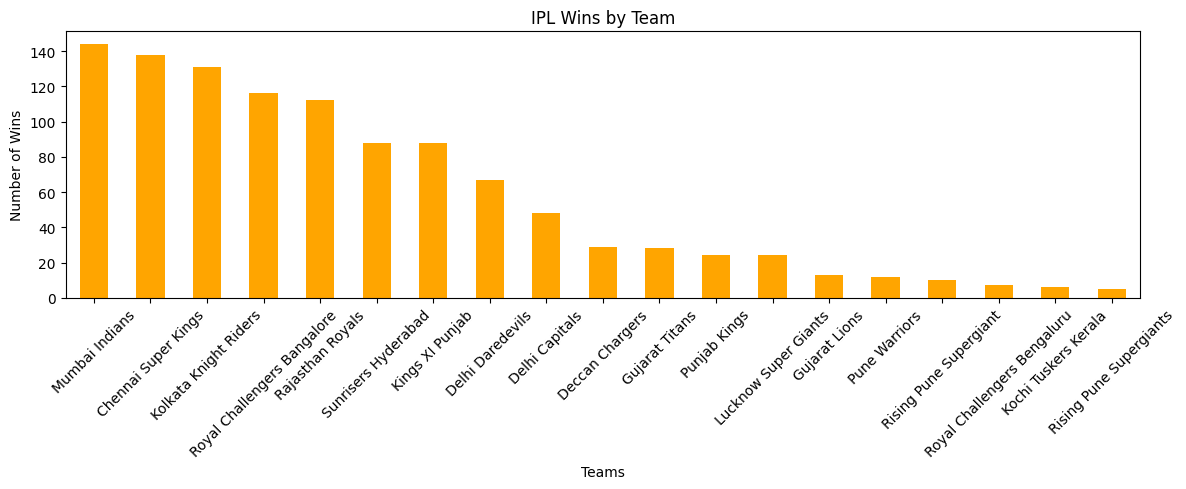

In [15]:
wins.plot(kind='bar', figsize=(12, 5),color='orange')
plt.title('IPL Wins by Team')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

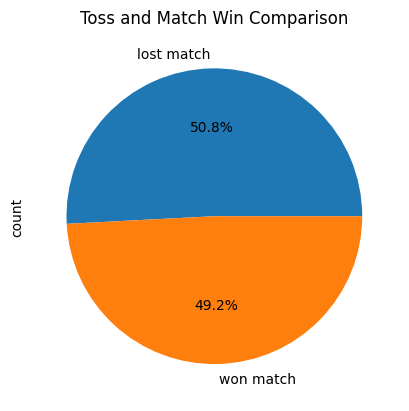

In [16]:
df['toss_match_win'] = df['toss_winner'] == df['winner']
df['toss_match_win'].value_counts().plot(kind='pie',labels=['lost match','won match'],autopct='%1.1f%%')
plt.title('Toss and Match Win Comparison')
plt.show()

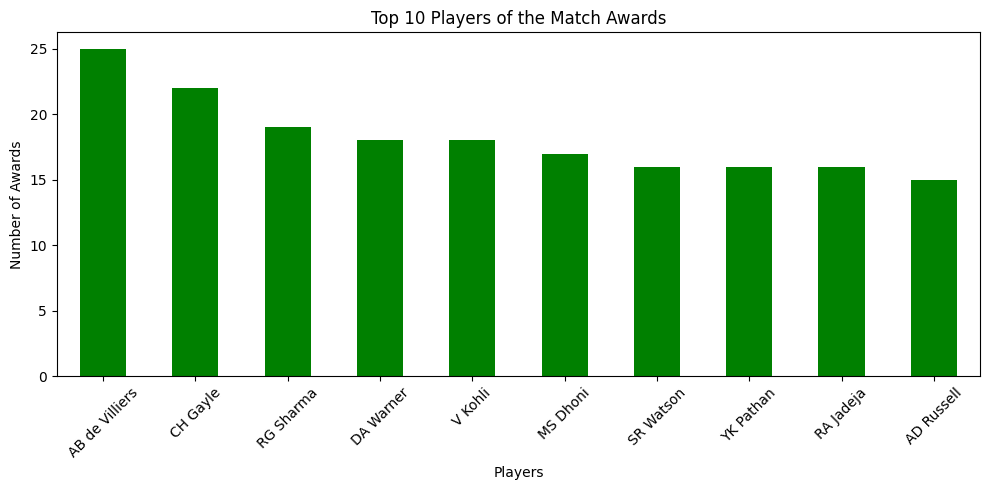

In [17]:
top_players = df['player_of_match'].value_counts().head(10)
top_players.plot(kind='bar', figsize=(10, 5), color='green')
plt.title('Top 10 Players of the Match Awards')
plt.xlabel('Players')
plt.ylabel('Number of Awards')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
deliveries = pd.read_csv("C:\\Users\\kiran\\OneDrive\\Desktop\\intern river\\deliveries.csv")
deliveries.head(5)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [25]:
run_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)
top_run_scorers = run_scorers.head(10)
print(top_run_scorers)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


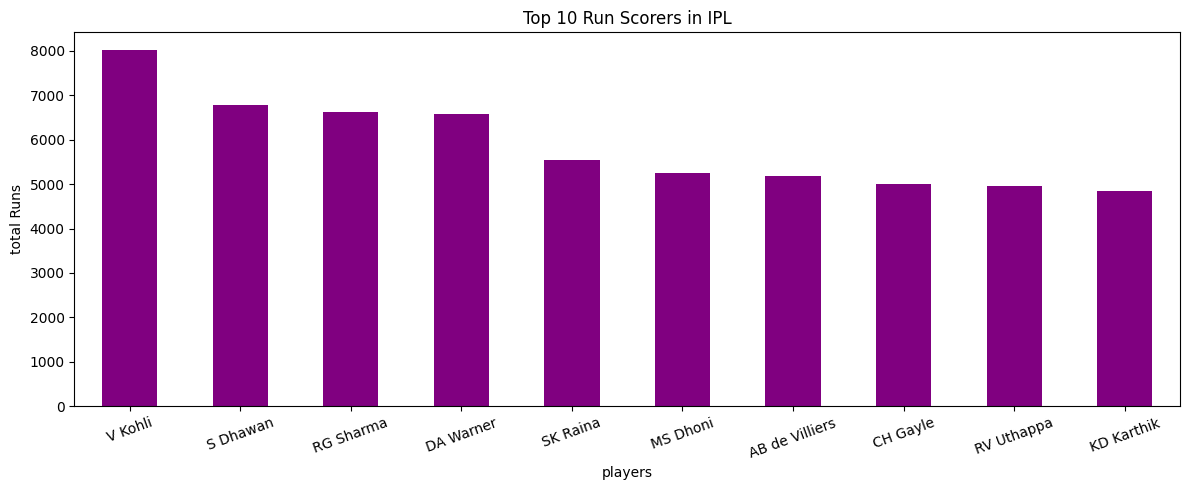

In [29]:
top_run_scorers.plot(kind='bar', figsize=(12, 5), color='purple')
plt.title('Top 10 Run Scorers in IPL')
plt.xlabel('players')
plt.ylabel('total Runs')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [35]:
total = pd.concat([df['team1'], df['team2']]).value_counts()
wins = df['winner'].value_counts()
win_pct = (wins/total * 100).dropna().sort_values(ascending=False).round(2)
print(win_pct)

Rising Pune Supergiant         62.50
Gujarat Titans                 62.22
Chennai Super Kings            57.98
Mumbai Indians                 55.17
Lucknow Super Giants           54.55
Delhi Capitals                 52.75
Kolkata Knight Riders          52.19
Rajasthan Royals               50.68
Sunrisers Hyderabad            48.35
Royal Challengers Bangalore    48.33
Royal Challengers Bengaluru    46.67
Kings XI Punjab                46.32
Gujarat Lions                  43.33
Punjab Kings                   42.86
Kochi Tuskers Kerala           42.86
Delhi Daredevils               41.61
Deccan Chargers                38.67
Rising Pune Supergiants        35.71
Pune Warriors                  26.09
Name: count, dtype: float64


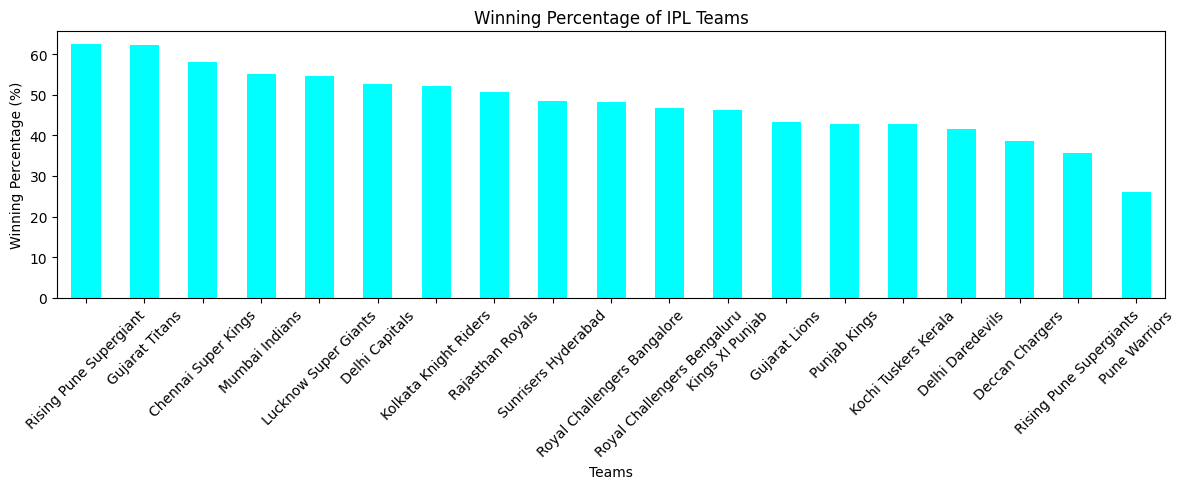

In [36]:
win_pct.plot(kind='bar', figsize=(12, 5), color='cyan')
plt.title('Winning Percentage of IPL Teams')
plt.xlabel('Teams')
plt.ylabel('Winning Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
merged = deliveries.merge(df[['id', 'season']], left_on='match_id', right_on='id')
print(merged.shape)

(260920, 19)


In [38]:
season_runs = merged.groupby(['season', 'batter'])['batsman_runs'].sum().reset_index()
top_per_season = season_runs.loc[season_runs.groupby('season')['batsman_runs'].idxmax()]
top_per_season =top_per_season.sort_values('season')
print(top_per_season)

       season         batter  batsman_runs
115   2007/08       SE Marsh           616
229      2009      ML Hayden           572
446   2009/10   SR Tendulkar           618
502      2011       CH Gayle           608
684      2012       CH Gayle           733
910      2013     MEK Hussey           733
1088     2014     RV Uthappa           660
1148     2015      DA Warner           562
1383     2016        V Kohli           973
1422     2017      DA Warner           641
1594     2018  KS Williamson           735
1694     2019      DA Warner           692
1866  2020/21       KL Rahul           676
2051     2021     RD Gaikwad           635
2144     2022     JC Buttler           863
2423     2023   Shubman Gill           890
2606     2024        V Kohli           741


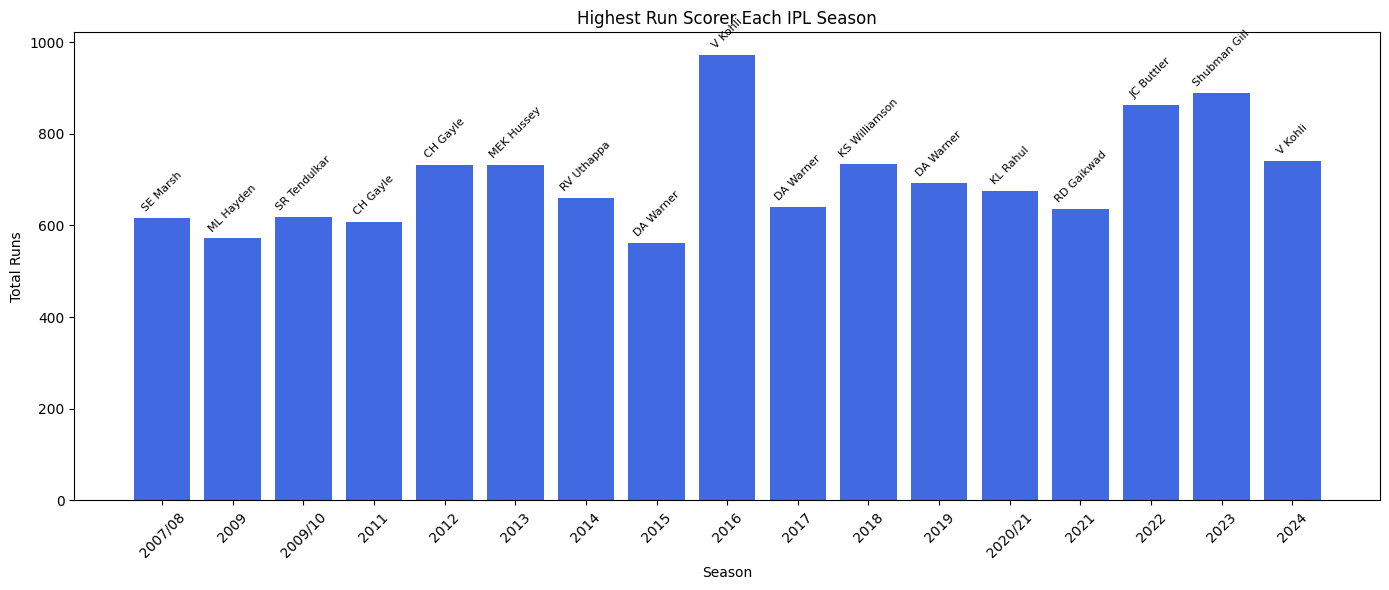

In [40]:
plt.figure(figsize=(14, 6))
bars = plt.bar(top_per_season['season'].astype(str), 
               top_per_season['batsman_runs'], 
               color='royalblue')

# Add player name on top of each bar
for bar, player in zip(bars, top_per_season['batter']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 10, 
             player, 
             ha='center', va='bottom', 
             fontsize=8, rotation=45)

plt.title('Highest Run Scorer Each IPL Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()